# Part 2 — Preprocessing Audio: DAIC-WOZ
**Pipeline**: Klasifikasi Kesehatan Mental Berbasis Audio (DAIC-WOZ)
**Peran**: ML & Data Engineer — Athila Ramdani Saputra

Notebook ini bertugas untuk:
1. Load audio `.wav` partisipan (16kHz mono)
2. Speaker Diarization: filter hanya segmen suara **Participant** (hapus Ellie)
3. Voice Activity Detection (VAD): buang bagian hening
4. Normalisasi amplitudo ke [-1, 1]
5. Simpan hasil preprocessing untuk digunakan di Part 3

**Catatan Anti-Leakage (Danylenko & Unold, 2025)**:
Gunakan TRANSCRIPT.csv untuk diarization, jangan ikutkan suara Ellie ke fitur.


In [1]:
import os
import sys
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")


Library berhasil diimport.


## Konfigurasi Path


In [2]:
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.path.abspath(os.getcwd())

BASE_DIR      = os.path.dirname(os.path.dirname(current_dir))
DAIC_DIR      = os.path.join(BASE_DIR, 'dataset', 'raw', 'DAIC-WOZ')
PROCESSED_DIR = os.path.join(BASE_DIR, 'dataset', 'processed')
OUTPUT_DIR    = os.path.join(BASE_DIR, 'docs', 'assets', 'images', 'daic')
META_PATH     = os.path.join(PROCESSED_DIR, 'daic_metadata.csv')

TARGET_SR = 16000  # Standar sampling rate untuk speech processing

print(f"DAIC-WOZ DIR : {DAIC_DIR}")
print(f"Target SR    : {TARGET_SR} Hz")


DAIC-WOZ DIR : d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ
Target SR    : 16000 Hz


## 2.1 — Load Metadata dari Part 1
Memuat daftar partisipan yang memiliki file lengkap.


In [3]:
df_meta = pd.read_csv(META_PATH)
df_valid = df_meta[df_meta['complete'] == True].copy()

print(f"Total partisipan valid (file lengkap): {len(df_valid)}")
print(df_valid[['participant_id', 'phq8_score', 'label_3kelas', 'severity']].head())


Total partisipan valid (file lengkap): 189
   participant_id  phq8_score  label_3kelas          severity
0             300          14             1  Kecemasan (5-14)
1             301           0             0      Stress (0-4)
2             302           5             1  Kecemasan (5-14)
3             303          14             1  Kecemasan (5-14)
4             304           8             1  Kecemasan (5-14)


## 2.2 — Fungsi: Speaker Diarization via TRANSCRIPT.csv
TRANSCRIPT.csv memuat kolom: `start_time`, `stop_time`, `speaker`, `value`
Kita hanya ambil segmen waktu di mana `speaker == 'Participant'`.


In [4]:
def get_participant_segments(transcript_path):
    """
    Membaca TRANSCRIPT.csv dan mengembalikan daftar tuple (start, stop)
    hanya untuk segmen suara Participant (bukan Ellie).
    """
    try:
        df = pd.read_csv(transcript_path, sep='\t')
        df.columns = [c.strip().lower() for c in df.columns]

        # Filter hanya segmen Participant
        df_p = df[df['speaker'].str.strip().str.lower() == 'participant'].copy()

        segments = list(zip(df_p['start_time'].astype(float),
                            df_p['stop_time'].astype(float)))
        return segments
    except Exception as e:
        print(f"  Warning: Gagal baca transcript — {e}")
        return []


def extract_participant_audio(y, sr, segments, min_duration=0.3):
    """
    Gabungkan hanya segmen audio yang termasuk suara Participant.
    min_duration: buang segmen yang terlalu pendek (< 0.3 detik)
    """
    chunks = []
    for (start, stop) in segments:
        duration = stop - start
        if duration < min_duration:
            continue
        start_idx = int(start * sr)
        stop_idx  = int(stop * sr)
        # Clip agar tidak melebihi panjang array
        stop_idx  = min(stop_idx, len(y))
        if start_idx < stop_idx:
            chunks.append(y[start_idx:stop_idx])
    if chunks:
        return np.concatenate(chunks)
    return np.array([])


## 2.3 — Fungsi: Voice Activity Detection (VAD)
Menghapus bagian hening (silence) dari audio menggunakan `librosa.effects.split`.


In [5]:
def apply_vad(y, sr, top_db=25, frame_length=512, hop_length=128):
    """
    Mendeteksi dan menggabungkan bagian aktif (non-hening) dari audio.
    top_db: ambang batas dB di bawah nilai maksimum untuk dianggap hening.
    """
    if len(y) == 0:
        return y
    # Dapatkan interval non-hening
    intervals = librosa.effects.split(y, top_db=top_db,
                                       frame_length=frame_length,
                                       hop_length=hop_length)
    if len(intervals) == 0:
        return y
    # Gabungkan semua interval aktif
    active_chunks = [y[start:end] for start, end in intervals]
    return np.concatenate(active_chunks)


## 2.4 — Fungsi: Normalisasi Amplitudo
Normalisasi ke range [-1, 1] agar semua partisipan dalam skala yang sama.


In [6]:
def normalize_audio(y):
    """Normalisasi peak amplitude ke [-1, 1]."""
    max_amp = np.max(np.abs(y))
    if max_amp > 0:
        return y / max_amp
    return y


## 2.5 — Pipeline Preprocessing Lengkap
Menggabungkan semua langkah: Load → Diarization → VAD → Normalisasi.


In [7]:
def preprocess_participant(pid, folder_path, sr=TARGET_SR):
    """
    Full preprocessing pipeline untuk satu partisipan.
    Returns: (y_clean, sr, info_dict) atau (None, None, info_dict) jika gagal.
    """
    audio_path      = os.path.join(folder_path, f"{pid}_AUDIO.wav")
    transcript_path = os.path.join(folder_path, f"{pid}_TRANSCRIPT.csv")

    info = {
        'participant_id'    : pid,
        'original_duration' : None,
        'after_diar_duration': None,
        'after_vad_duration' : None,
        'n_segments'        : 0,
        'status'            : 'ok',
    }

    # Step 1: Load audio
    try:
        y_raw, sr_orig = librosa.load(audio_path, sr=sr, mono=True)
        info['original_duration'] = len(y_raw) / sr
    except Exception as e:
        info['status'] = f'error_load: {e}'
        return None, None, info

    # Step 2: Speaker Diarization
    segments = get_participant_segments(transcript_path)
    info['n_segments'] = len(segments)

    if segments:
        y_diar = extract_participant_audio(y_raw, sr, segments)
    else:
        # Fallback: gunakan seluruh audio jika transkrip tidak tersedia
        y_diar = y_raw

    if len(y_diar) == 0:
        info['status'] = 'error_empty_after_diar'
        return None, None, info
    info['after_diar_duration'] = len(y_diar) / sr

    # Step 3: VAD
    y_vad = apply_vad(y_diar, sr)
    if len(y_vad) == 0:
        y_vad = y_diar  # Fallback jika VAD menghapus semua
    info['after_vad_duration'] = len(y_vad) / sr

    # Step 4: Normalisasi
    y_clean = normalize_audio(y_vad)

    return y_clean, sr, info


## 2.6 — Demonstrasi: Visualisasi Satu Partisipan
Menampilkan waveform sebelum dan sesudah preprocessing untuk satu partisipan.


Memproses partisipan demo: 300...

Hasil Preprocessing:
  Durasi asli           : 648.5 detik
  Setelah Diarization   : 155.8 detik
  Setelah VAD           : 61.6 detik
  Jumlah segmen Participant: 87


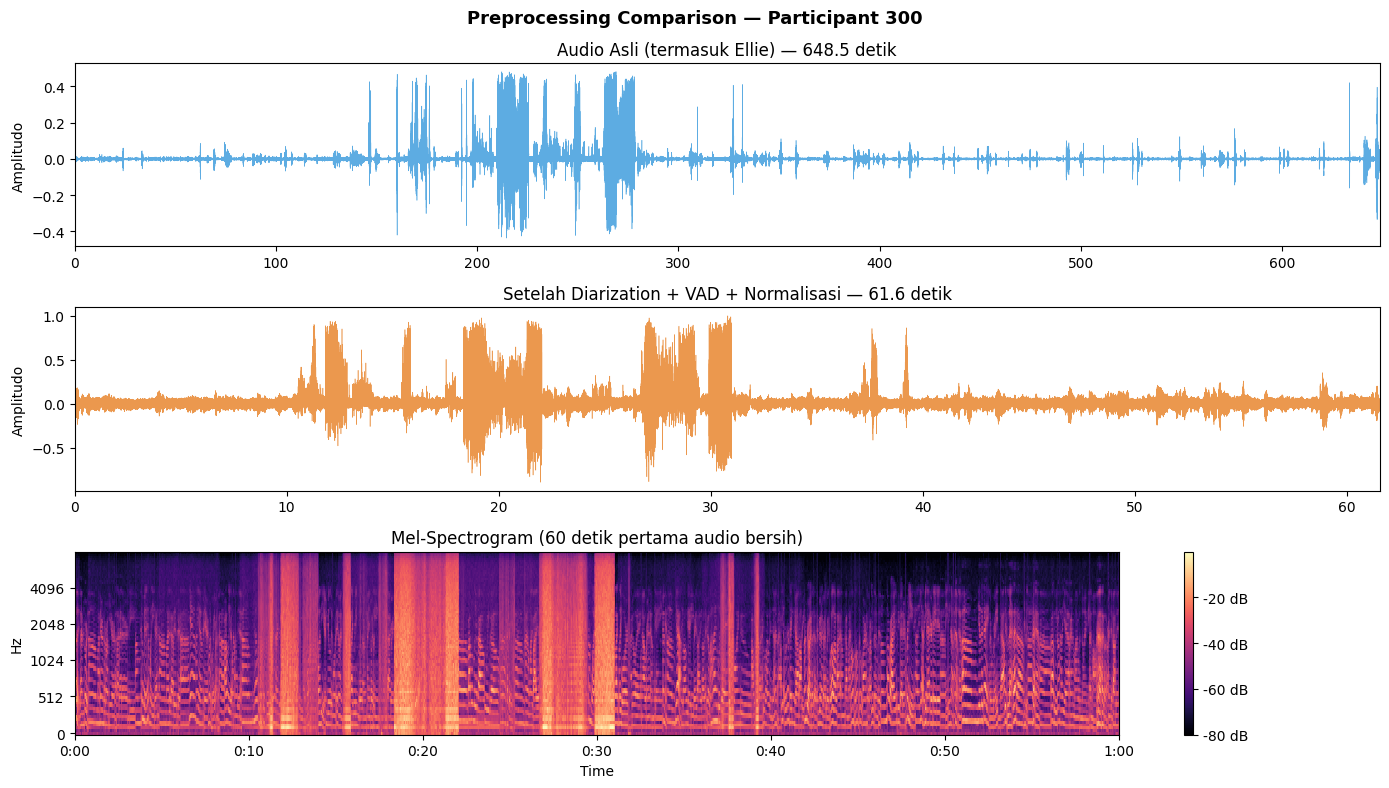

Visualisasi tersimpan.


In [8]:
DEMO_PID    = 300
DEMO_FOLDER = os.path.join(DAIC_DIR, f"{DEMO_PID}_P")

print(f"Memproses partisipan demo: {DEMO_PID}...")
y_clean_demo, sr_demo, info_demo = preprocess_participant(DEMO_PID, DEMO_FOLDER)

if y_clean_demo is not None:
    print(f"\nHasil Preprocessing:")
    print(f"  Durasi asli           : {info_demo['original_duration']:.1f} detik")
    print(f"  Setelah Diarization   : {info_demo['after_diar_duration']:.1f} detik")
    print(f"  Setelah VAD           : {info_demo['after_vad_duration']:.1f} detik")
    print(f"  Jumlah segmen Participant: {info_demo['n_segments']}")

    # Load audio asli untuk perbandingan
    y_raw_demo, _ = librosa.load(os.path.join(DEMO_FOLDER, f"{DEMO_PID}_AUDIO.wav"),
                                  sr=TARGET_SR, mono=True)

    # Plot perbandingan waveform
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    fig.suptitle(f'Preprocessing Comparison — Participant {DEMO_PID}', fontsize=13, fontweight='bold')

    # Waveform asli
    t_raw = np.linspace(0, len(y_raw_demo)/TARGET_SR, len(y_raw_demo))
    axes[0].plot(t_raw, y_raw_demo, color='#3498db', linewidth=0.4, alpha=0.8)
    axes[0].set_title(f'Audio Asli (termasuk Ellie) — {info_demo["original_duration"]:.1f} detik')
    axes[0].set_ylabel('Amplitudo')
    axes[0].set_xlim([0, t_raw[-1]])

    # Waveform setelah diarization
    t_clean = np.linspace(0, len(y_clean_demo)/TARGET_SR, len(y_clean_demo))
    axes[1].plot(t_clean, y_clean_demo, color='#e67e22', linewidth=0.4, alpha=0.8)
    axes[1].set_title(f'Setelah Diarization + VAD + Normalisasi — {info_demo["after_vad_duration"]:.1f} detik')
    axes[1].set_ylabel('Amplitudo')
    axes[1].set_xlim([0, t_clean[-1]])

    # Mel-spectrogram audio bersih (5 menit pertama agar cepat)
    y_spec = y_clean_demo[:TARGET_SR * 60]  # 60 detik pertama
    S = librosa.feature.melspectrogram(y=y_spec, sr=TARGET_SR, n_mels=80)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=TARGET_SR, hop_length=512,
                                    x_axis='time', y_axis='mel', ax=axes[2],
                                    cmap='magma')
    axes[2].set_title('Mel-Spectrogram (60 detik pertama audio bersih)')
    fig.colorbar(img, ax=axes[2], format='%+2.0f dB')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'p2_preprocessing_demo.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Visualisasi tersimpan.")
else:
    print(f"Gagal preprocessing: {info_demo['status']}")


## 2.7 — Batch Preprocessing Semua Partisipan
Menjalankan preprocessing ke seluruh partisipan dan menyimpan informasi statistiknya.
Audio bersih **tidak disimpan ke disk** — langsung diproses ke feature extraction
pada Part 3 untuk efisiensi penyimpanan.


In [9]:
print("Menjalankan batch preprocessing...")
print("(Audio bersih tidak disimpan — langsung diteruskan ke Part 3)\n")

preprocess_info_list = []
failed_pids = []

for idx, row in df_valid.iterrows():
    pid   = row['participant_id']
    fpath = row['folder_path']

    _, _, info = preprocess_participant(pid, fpath)

    if info['status'] == 'ok':
        preprocess_info_list.append(info)
    else:
        failed_pids.append(pid)
        print(f"  [FAIL] PID {pid}: {info['status']}")

df_preprocess = pd.DataFrame(preprocess_info_list)
df_preprocess_out = os.path.join(PROCESSED_DIR, 'daic_preprocess_info.csv')
df_preprocess.to_csv(df_preprocess_out, index=False)

print(f"\nSelesai!")
print(f"  Berhasil diproses : {len(preprocess_info_list)} partisipan")
print(f"  Gagal             : {len(failed_pids)} partisipan {failed_pids}")
print(f"  Info tersimpan di : {df_preprocess_out}")


Menjalankan batch preprocessing...
(Audio bersih tidak disimpan — langsung diteruskan ke Part 3)


Selesai!
  Berhasil diproses : 189 partisipan
  Gagal             : 0 partisipan []
  Info tersimpan di : d:\repositories\menthealth-ml\dataset\processed\daic_preprocess_info.csv


## 2.8 — Statistik Preprocessing


In [10]:
if not df_preprocess.empty:
    print("=== Statistik Durasi Audio ===")
    stats = df_preprocess[['original_duration', 'after_diar_duration', 'after_vad_duration']].describe().round(1)
    print(stats)

    reduction_pct = (
        (df_preprocess['original_duration'] - df_preprocess['after_vad_duration'])
        / df_preprocess['original_duration'] * 100
    ).mean()
    print(f"\nRata-rata pengurangan durasi setelah diarization + VAD: {reduction_pct:.1f}%")
    print("(Ini adalah durasi suara Ellie + hening yang berhasil dihapus)")

=== Statistik Durasi Audio ===
       original_duration  after_diar_duration  after_vad_duration
count              189.0                189.0               189.0
mean               956.3                464.8               232.4
std                270.0                235.7               146.0
min                414.8                 62.2                 0.9
25%                785.6                295.1               126.5
50%                911.7                428.5               225.0
75%               1056.8                591.1               302.5
max               1966.2               1280.9               762.1

Rata-rata pengurangan durasi setelah diarization + VAD: 76.6%
(Ini adalah durasi suara Ellie + hening yang berhasil dihapus)
